In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path

sys.path.append('../../interspeech-2020-perceptimatic/')
SAVE_DIR = Path("matrices_mfcc_sauvegardees")

In [2]:

from compute_results_weighted_human import (
    get_score_humans,
    get_score_model as get_score_model_weighted,
    compute_score as compute_score_weighted,
)
from compute_results_unweighted import (
    get_score_model as get_score_model_unweighted,
    compute_score as compute_score_unweighted,
)

In [3]:

def corriger_biais_certitude(df: pd.DataFrame,
                              vote_col: str = 'correct_answer',
                              rater_col: str = 'individual') -> pd.DataFrame:
    df = df.copy()

    certitude = df[vote_col].abs()                         # |vote| ∈ {1,2,3}
    mu_i      = certitude.groupby(df[rater_col]).transform('mean')  # µ_i par testeur
    x_i       = 2 - mu_i                                  # décalage individuel

    certitude_corrigee = (certitude + x_i)    # on reste dans [1,3]
    df[vote_col]       = certitude_corrigee * np.sign(df[vote_col])  # on remet le signe

    return df


def charger_et_corriger(chemin_csv: str) -> pd.DataFrame:
    """Charge un CSV et applique la correction en place sur correct_answer."""
    df = pd.read_csv(chemin_csv)
    return corriger_biais_certitude(df)

In [4]:
from scipy.stats import linregress
import matplotlib.pyplot as plt

def plot_correlations(chemin_gow, chemin_pow, figsize=(15, 5)):
    df_gow = charger_et_corriger(chemin_gow)
    df_pow = charger_et_corriger(chemin_pow)

    configs = [
        {
            'df'        : df_gow,
            'col_model' : 'Delta_Machine_GOW',
            'label'     : 'GOW',
            'color'     : 'steelblue',
        },
        {
            'df'        : df_gow,
            'col_model' : 'Delta_Machine_DTW_PERSO',
            'label'     : 'DTW PERSO',
            'color'     : 'seagreen',
        },
        {
            'df'        : df_pow,
            'col_model' : 'Delta_Machine_POW',
            'label'     : 'POW',
            'color'     : 'tomato',
        },
    ]

    fig, axes = plt.subplots(1, len(configs), figsize=figsize)

    for ax, cfg in zip(axes, configs):
        df   = cfg['df']
        col  = cfg['col_model']
        mask = df['correct_answer'].notna() & df[col].notna() 
        
        x_raw = df.loc[mask, col].values                # delta modèle  -> abscisses
        y_raw = df.loc[mask, 'correct_answer'].values   # delta humain  -> ordonnées

        # Normalisation [0, 1] indépendante pour chaque axe
        def norm(v):
            vmin, vmax = v.min(), v.max()
            return (v - vmin) / (vmax - vmin)

        x = norm(x_raw)
        y = norm(y_raw)

        # Régression linéaire sur les valeurs normalisées
        slope, intercept, r, p, _ = linregress(x, y)

        # Points
        ax.scatter(x, y, alpha=0.3, s=10, color=cfg['color'])

        # Droite de régression
        x_line = np.linspace(0, 1, 200)
        ax.plot(x_line, slope * x_line + intercept, color='black', linewidth=1.5)

        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f"{cfg['label']}\nr = {r:.3f}  (p = {p:.2e})", fontsize=12, fontweight='bold')
        ax.set_xlabel(f"Delta modèle — {cfg['label']} (normalisé)", fontsize=10)
        ax.set_ylabel("Delta humain — correct_answer (normalisé)", fontsize=10)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.suptitle("Corrélation Delta modèle vs Delta humain", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

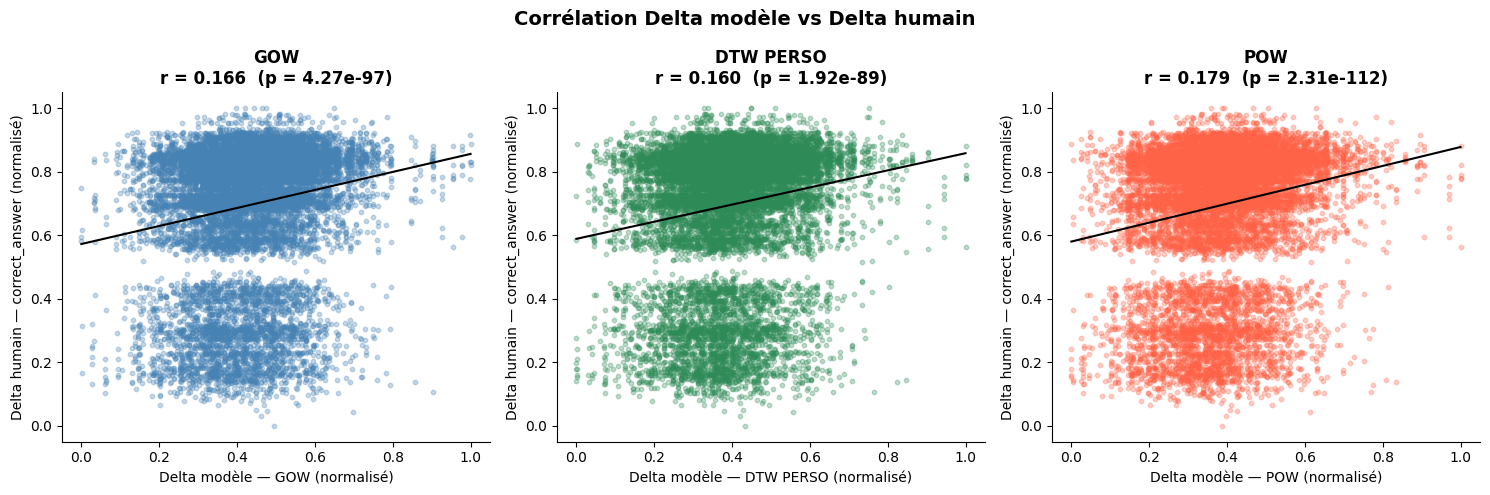

In [5]:
plot_correlations(
    chemin_gow="matrices_mfcc_sauvegardees/resultats_gow_WO_OT.csv",
    chemin_pow="matrices_mfcc_sauvegardees/resultats_pow_WO_OT.csv",
)

In [ ]:
def plot_correlations_by_tripletid(chemin_gow, chemin_pow, figsize=(18, 10)):
    # 1. Chargement des données
    df_gow = charger_et_corriger(chemin_gow)
    df_pow = charger_et_corriger(chemin_pow)

    # 2. Création du triplet_id pour les deux DataFrames
    for df in [df_gow, df_pow]:
        if 'triplet_id' not in df.columns:
            df['triplet_id'] = (
                df['language'].astype(str) + "_" +
                df['prev_phone'].astype(str) + "-" +
                df['next_phone'].astype(str) + "-" +
                df['TGT'].astype(str) + "-" +
                df['OTH'].astype(str)
            )

    langues = df_gow['language'].dropna().unique()

    configs = [
        {'df': df_gow, 'col_model': 'Delta_Machine_DTW_PERSO', 'label': 'Notre DTW','color': 'seagreen' },
        {'df': df_gow, 'col_model': 'Delta_Machine_GOW',       'label': 'GOW',      'color': 'steelblue'},
        {'df': df_pow, 'col_model': 'Delta_Machine_POW',       'label': 'POW',      'color': 'tomato'   },
    ]

    # tailles de police agrandies
    TITLE_FS  = 16   # titres des sous-graphes  
    LABEL_FS  = 13   # labels x / y             
    TICK_FS   = 12   # graduations des axes
    SUPTITLE_FS = 20 # titre général            

    fig, axes = plt.subplots(len(langues), len(configs), figsize=figsize)
    if len(langues) == 1:
        axes = [axes]

    for i, langue in enumerate(langues):
        for j, cfg in enumerate(configs):
            ax = axes[i][j]
            df = cfg['df']
            col_model = cfg['col_model']

            mask = (
                (df['language'] == langue) &
                df['correct_answer'].notna() &
                df[col_model].notna()
            )
            df_clean = df[mask]

            df_agg = df_clean.groupby('triplet_id').agg(
                {col_model: 'mean', 'correct_answer': 'mean'}
            ).reset_index()

            x_raw = df_agg[col_model].values
            y_raw = df_agg['correct_answer'].values

            def norm(v):
                vmin, vmax = v.min(), v.max()
                if vmax == vmin:
                    return np.zeros_like(v)
                return (v - vmin) / (vmax - vmin)

            x = norm(x_raw)
            y = norm(y_raw)

            slope, intercept, r, p, _ = linregress(x, y)

            ax.scatter(x, y, alpha=0.6, s=20, color=cfg['color'])
            x_line = np.linspace(0, 1, 200)
            ax.plot(x_line, slope * x_line + intercept, color='black', linewidth=1.5)

            ax.set_xlim(-0.05, 1.05)
            ax.set_ylim(-0.05, 1.05)

            titre = f"{cfg['label']} - {str(langue).upper()}\nr = {r:.3f}  (p = {p:.2e})"
            ax.set_title(titre, fontsize=TITLE_FS, fontweight='bold')  

            ax.tick_params(axis='both', labelsize=TICK_FS)

            if i == len(langues) - 1:
                ax.set_xlabel(f"Delta {cfg['label']} (normalisé)", fontsize=LABEL_FS)  
            if j == 0:
                ax.set_ylabel(f"Score humain ({str(langue).capitalize()})", fontsize=LABEL_FS) 

            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

    plt.suptitle(
        "Corrélation Modèle vs Humain par Contexte Phonétique (triplet_id)",
        fontsize=SUPTITLE_FS, fontweight='bold', y=1.02  
    )
    plt.tight_layout()
    plt.show()

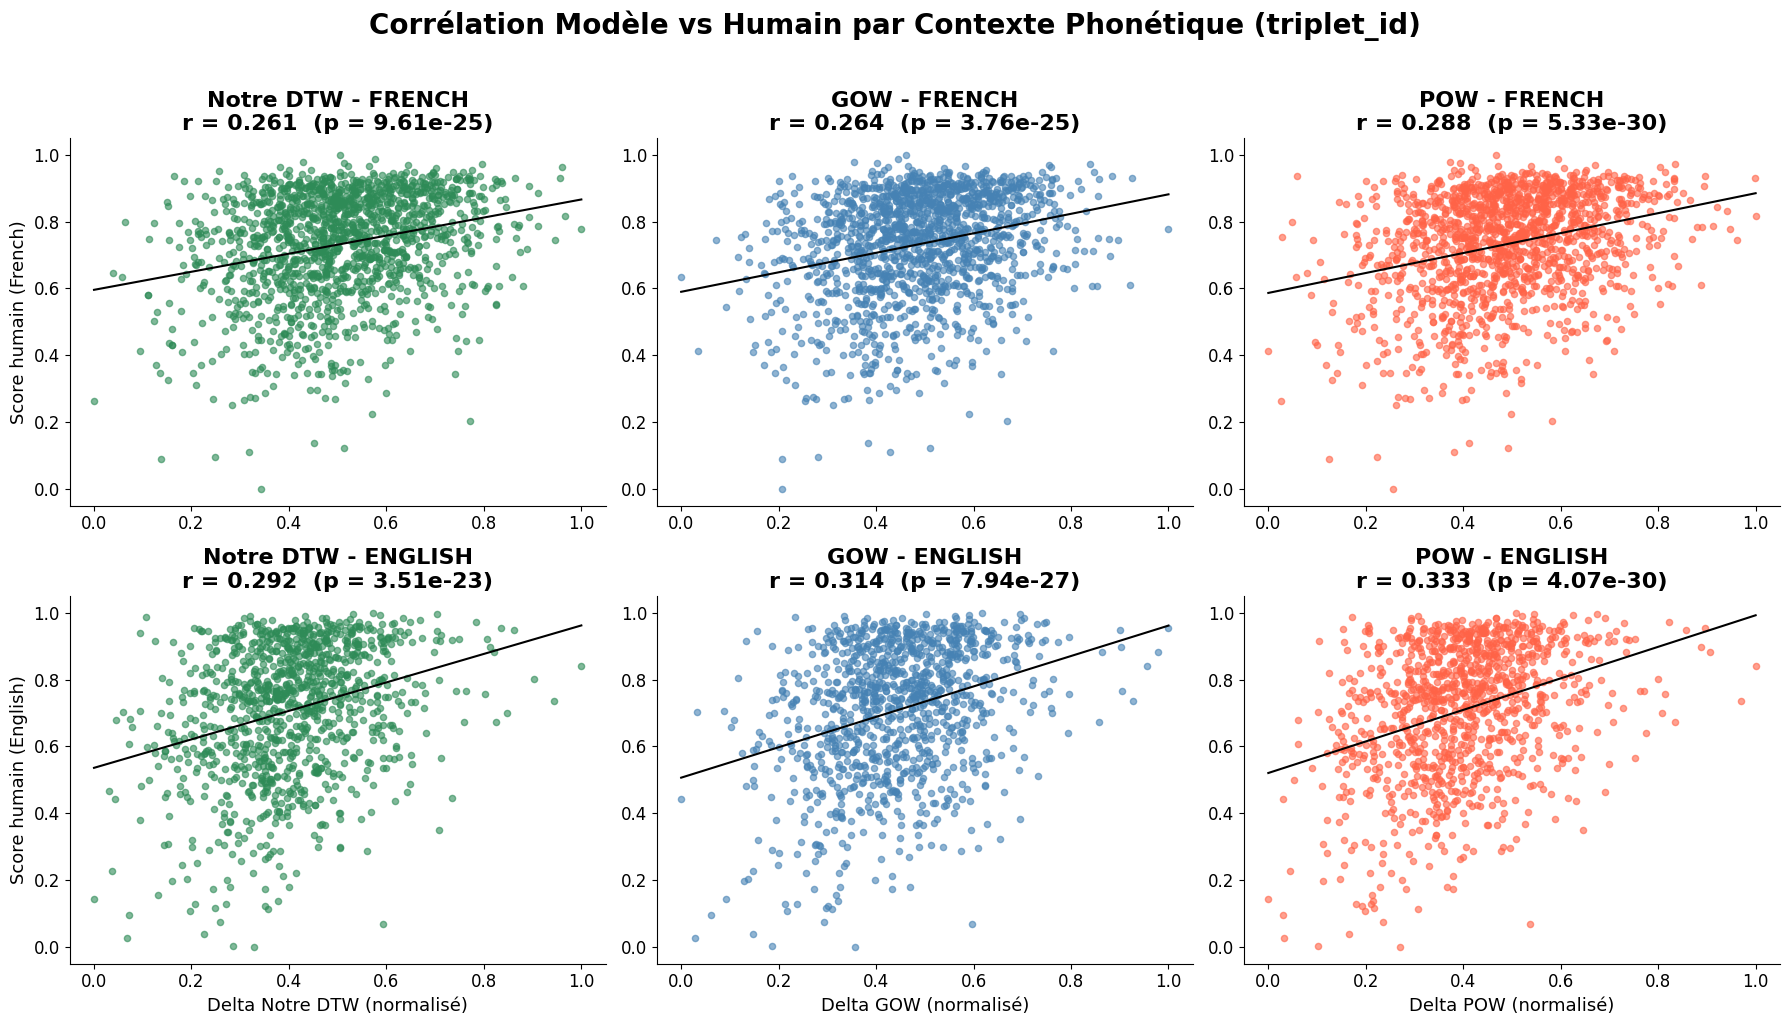

In [7]:
plot_correlations_by_tripletid(
    chemin_gow="matrices_mfcc_sauvegardees/resultats_gow_WO_OT.csv",
    chemin_pow="matrices_mfcc_sauvegardees/resultats_pow_WO_OT.csv",
)

In [8]:
def plot_correlations_filtered(chemin_gow, chemin_pow, filtre='correct', figsize=(18, 10)):

    # 1. Chargement des données
    df_gow = charger_et_corriger(chemin_gow)
    df_pow = charger_et_corriger(chemin_pow)

    # 2. Création du triplet_id
    for df in [df_gow, df_pow]:
        if 'triplet_id' not in df.columns:
            df['triplet_id'] = (
                df['language'].astype(str) + "_" +
                df['prev_phone'].astype(str) + "-" +
                df['next_phone'].astype(str) + "-" +
                df['TGT'].astype(str) + "-" +
                df['OTH'].astype(str)
            )

    langues = df_gow['language'].dropna().unique()

    configs = [
        {'df': df_gow, 'col_model': 'Delta_Machine_DTW_PERSO', 'label': 'Notre DTW', 'color': 'seagreen' },
        {'df': df_gow, 'col_model': 'Delta_Machine_GOW',       'label': 'GOW',       'color': 'steelblue'},
        {'df': df_pow, 'col_model': 'Delta_Machine_POW',       'label': 'POW',        'color': 'tomato'  },
    ]

    # tailles de police agrandies 
    TITLE_FS    = 16   # titres des sous-graphes  
    LABEL_FS    = 13   # labels x / y           
    TICK_FS     = 12   # graduations des axes
    SUPTITLE_FS = 20   # titre général          

    fig, axes = plt.subplots(len(langues), len(configs), figsize=figsize)
    if len(langues) == 1:
        axes = [axes]

    for i, langue in enumerate(langues):
        for j, cfg in enumerate(configs):
            ax = axes[i][j]
            df = cfg['df']
            col_model = cfg['col_model']

            # 3. Application du masque global
            mask_base = (
                (df['language'] == langue) &
                df['correct_answer'].notna() &
                df[col_model].notna()
            )

            # 4. Le filtre
            if filtre == 'correct':
                mask_filtre = df['binarized_answer'] > 0
            elif filtre == 'erreur':
                mask_filtre = df['binarized_answer'] < 0
            else:
                mask_filtre = True  # par défaut, on garde tout

            df_clean = df[mask_base & mask_filtre]

            # 5. Agrégation sur les données filtrées
            df_agg = df_clean.groupby('triplet_id').agg(
                {col_model: 'mean', 'correct_answer': 'mean'}
            ).reset_index()

            x_raw = df_agg[col_model].values
            y_raw = df_agg['correct_answer'].values

            def norm(v):
                vmin, vmax = v.min(), v.max()
                if vmax == vmin:
                    return np.zeros_like(v)
                return (v - vmin) / (vmax - vmin)

            x = norm(x_raw)
            y = norm(y_raw)

            slope, intercept, r, p, _ = linregress(x, y)

            ax.scatter(x, y, alpha=0.6, s=20, color=cfg['color'])
            x_line = np.linspace(0, 1, 200)
            ax.plot(x_line, slope * x_line + intercept, color='black', linewidth=1.5)

            ax.set_xlim(-0.05, 1.05)
            ax.set_ylim(-0.05, 1.05)

            titre = f"{cfg['label']} - {str(langue).upper()}\nr = {r:.3f}  (p = {p:.2e})"
            ax.set_title(titre, fontsize=TITLE_FS, fontweight='bold')     

            ax.tick_params(axis='both', labelsize=TICK_FS)               

            if i == len(langues) - 1:
                ax.set_xlabel(f"Delta {cfg['label']} (normalisé)", fontsize=LABEL_FS)  
            if j == 0:
                ax.set_ylabel(f"Score Humain ({filtre})", fontsize=LABEL_FS)           

            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(alpha=0.3)

    titre_global = f"Corrélation Modèle vs Humain : {'RÉUSSITES' if filtre == 'correct' else 'ERREURS'} (triplet_id)"
    plt.suptitle(titre_global, fontsize=SUPTITLE_FS, fontweight='bold', y=1.02) 
    plt.tight_layout()
    plt.show()

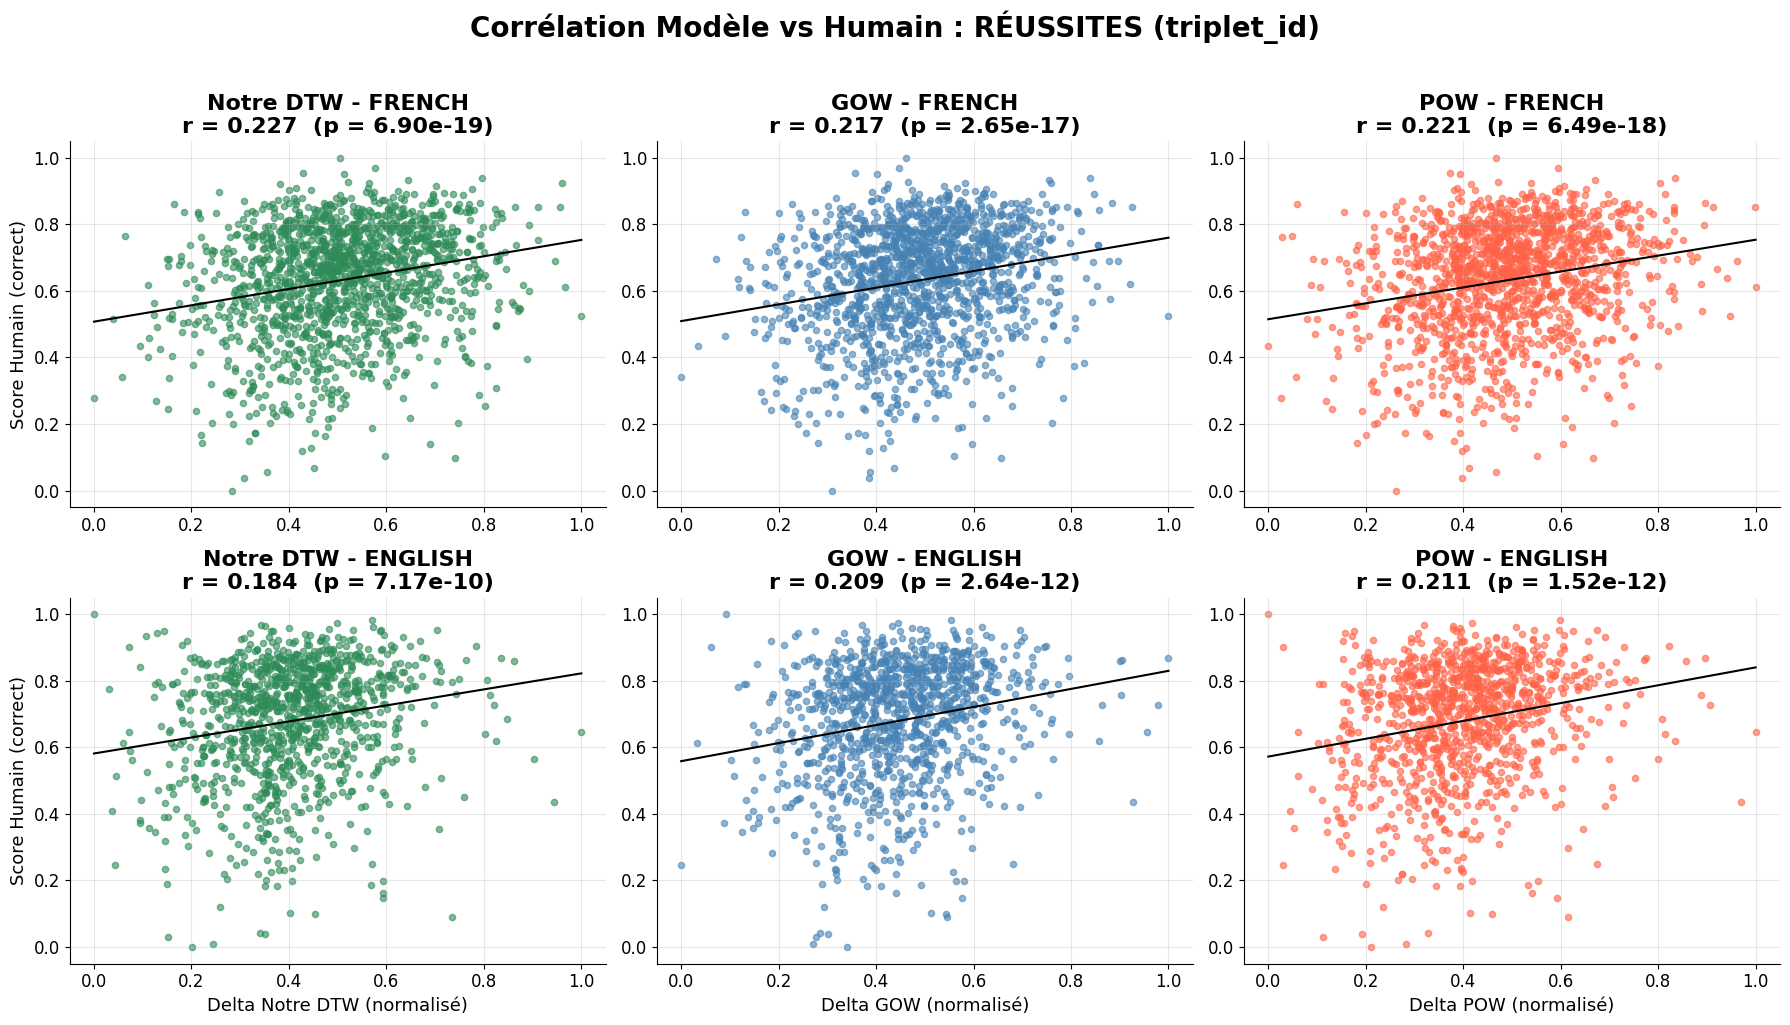

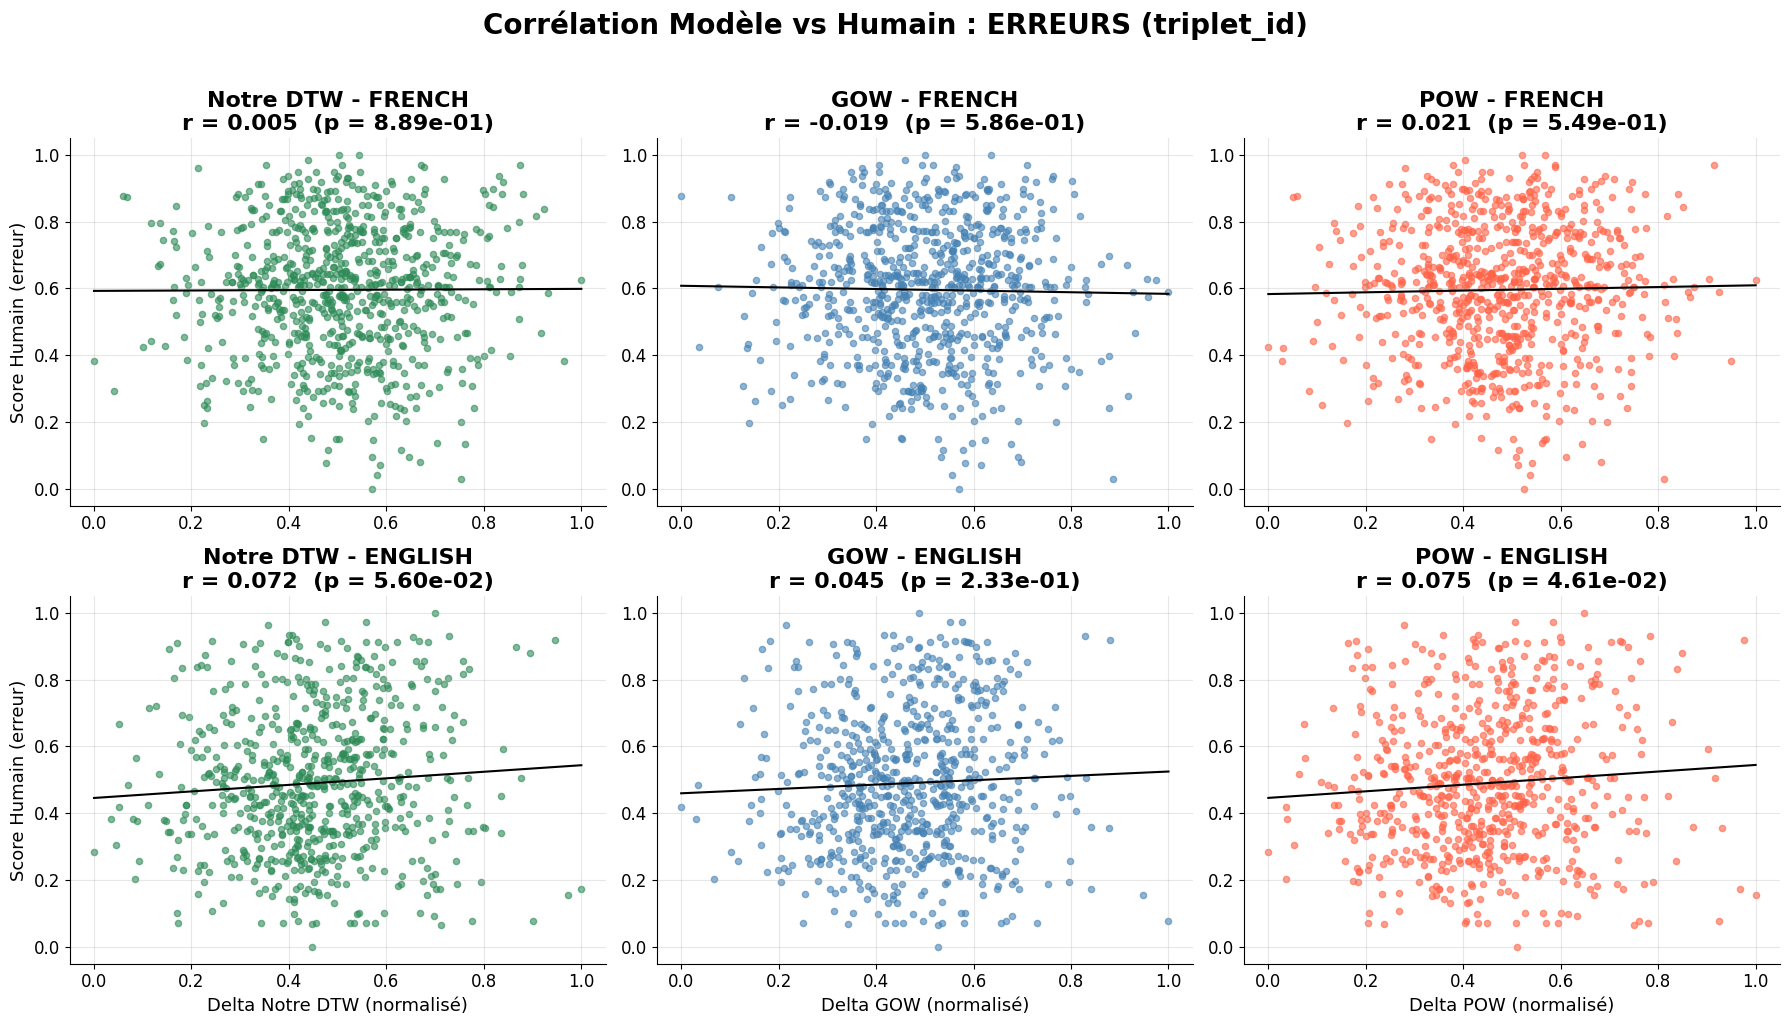

In [9]:
plot_correlations_filtered(
    chemin_gow="matrices_mfcc_sauvegardees/resultats_gow_WO_OT.csv",
    chemin_pow="matrices_mfcc_sauvegardees/resultats_pow_WO_OT.csv",
    filtre='correct'
)
plot_correlations_filtered(
    chemin_gow="matrices_mfcc_sauvegardees/resultats_gow_WO_OT.csv",
    chemin_pow="matrices_mfcc_sauvegardees/resultats_pow_WO_OT.csv",
    filtre='erreur'
)

In [ ]:
from scipy.stats import chi2, chi2_contingency
from tqdm import tqdm

def plot_confusion_matrices(chemin_gow, chemin_pow, figsize=(20, 5), n_bootstrap=1000, seed=42):

    df_gow = charger_et_corriger(chemin_gow)
    df_pow = charger_et_corriger(chemin_pow)

    configs = [
        {'df': df_gow, 'col_model': 'Delta_Machine_GOW',       'label': 'GOW',              'cmap': 'Blues'},
        {'df': df_gow, 'col_model': 'Delta_Machine_DTW_PERSO', 'label': 'Notre DTW',        'cmap': 'Greens'},
        {'df': df_pow, 'col_model': 'Delta_Machine_POW',       'label': 'POW',              'cmap': 'Reds'},
        {'df': df_gow, 'col_model': 'Humain',                  'label': 'Humain vs Humain', 'cmap': 'Purples'},
    ]

    langues = sorted(df_gow['language'].dropna().unique())

    fig, axes = plt.subplots(len(langues), len(configs),
                             figsize=(figsize[0], figsize[1] * len(langues)))
    if len(langues) == 1:
        axes = [axes]

    rng = np.random.default_rng(seed)

    for i, langue in enumerate(langues):
        for j, cfg in enumerate(configs):
            ax = axes[i][j]
            df = cfg['df']
            col = cfg['col_model']

            # Filtrer par langue + valeurs valides
            mask = (df['language'] == langue) & df['correct_answer'].notna()
            if col != 'Humain':
                mask = mask & df[col].notna()
            df_lang = df[mask].copy()

            if cfg['label'] == 'Humain vs Humain':
                # --- LOGIQUE BOOTSTRAP PLAFOND HUMAIN ---
                
                participants = df_lang['individual'].unique()
                matrices_counts = []

                for _ in range(n_bootstrap):
                    rng.shuffle(participants)
                    mid = len(participants) // 2

                    df1 = df_lang[df_lang['individual'].isin(participants[:mid])]
                    df2 = df_lang[df_lang['individual'].isin(participants[mid:])]

                    cols_merge = ['filename', 'correct_answer']
                    merged = pd.merge(
                        df1[cols_merge].rename(columns={'correct_answer': 'h1'}),
                        df2[cols_merge].rename(columns={'correct_answer': 'h2'}),
                        on='filename'
                    ).dropna()

                    if len(merged) < 10:
                        continue

                    h1_correct = merged['h1'] > 0
                    h2_correct = merged['h2'] > 0

                    matrice_C = np.array([
                        [(h1_correct  &  h2_correct).sum(), (h1_correct  & ~h2_correct).sum()],
                        [(~h1_correct &  h2_correct).sum(), (~h1_correct & ~h2_correct).sum()],
                    ])
                    matrices_counts.append(matrice_C)

                # Calcul des moyennes sur les itérations bootstrap
                counts = np.mean(matrices_counts, axis=0).astype(int)
                total1 = counts[0].sum()
                total2 = counts[1].sum()
                
                props1 = counts[0] / total1 if total1 > 0 else np.array([0, 0])
                props2 = counts[1] / total2 if total2 > 0 else np.array([0, 0])
                props = np.array([props1, props2])

                total_all = total1 + total2
                humain_correct_accuracy = total1 / total_all if total_all > 0 else 0
                model_correct_accuracy = (counts[0,0] + counts[1,0]) / total_all if total_all > 0 else 0
                
            else:
                # --- LOGIQUE CLASSIQUE POUR LES MODÈLES ---
                humain_correct = df_lang['correct_answer'] > 0
                model_correct  = df_lang[col] > 0
        
                humain_correct_accuracy = df_lang[humain_correct].shape[0] / df_lang.shape[0]
                model_correct_accuracy = df_lang[model_correct].shape[0] / df_lang.shape[0]

                counts = np.array([
                    [(humain_correct  &  model_correct).sum(), (humain_correct  & ~model_correct).sum()],
                    [(~humain_correct &  model_correct).sum(), (~humain_correct & ~model_correct).sum()],
                ])

                total1 = counts[0].sum()
                total2 = counts[1].sum()
                props1 = counts[0] / total1 if total1 > 0 else np.array([0, 0])
                props2 = counts[1] / total2 if total2 > 0 else np.array([0, 0])
                props = np.array([props1, props2])


            ax.imshow(props, cmap=cfg['cmap'], vmin=0, vmax=props.max() * 1.3)

            for r in range(2):
                for c in range(2):
                    ax.text(c, r,
                            f"{props[r,c]*100:.1f}%\n(n={counts[r,c]})",
                            ha='center', va='center', fontsize=15, fontweight='bold',
                            color='white' if props[r,c] > props.max() * 0.6 else 'black')

            ax.set_xticks([0, 1])
            ax.set_yticks([0, 1])
            ax.set_xticklabels([f"{'G2' if cfg['label'] == 'Humain vs Humain' else 'Modèle'}\ncorrect {model_correct_accuracy*100:.1f}%", 
                                f"{'G2' if cfg['label'] == 'Humain vs Humain' else 'Modèle'}\nerreur {100 - model_correct_accuracy*100:.1f}%"], fontsize=13)

            if cfg['label'] == 'Humain vs Humain':
                ax.set_yticklabels([f"G1\ncorrect {humain_correct_accuracy*100:.1f}%",
                                    f"G1\nerreur {100 - humain_correct_accuracy*100:.1f}%"], fontsize=13)
            elif j == 0:
                ax.set_yticklabels([f"Humain\ncorrect {humain_correct_accuracy*100:.1f}%",
                                    f"Humain\nerreur {100 - humain_correct_accuracy*100:.1f}%"], fontsize=13)
            else:
                ax.set_yticklabels(["Humain\ncorrect", "Humain\nerreur"], fontsize=13)

            ax.set_title(f"{cfg['label']} — {str(langue).upper()}  (n={total1 + total2})",
                         fontsize=14, fontweight='bold', pad=10)
            ax.tick_params(length=0)
            ax.grid(alpha=0.3)

            # --- AJOUT STATISTIQUES (ODDS RATIO, MCNEMAR & CHI2 D'INDÉPENDANCE) ---
            A, B = counts[0, 0], counts[0, 1]
            C, D = counts[1, 0], counts[1, 1]

            # 1. Odds Ratio (force de l'association)
            odds_ratio = (A * D) / (B * C) if (B * C) != 0 else np.nan

            # 2. Test de McNemar (teste la symétrie B=C, i.e. accuracy modèle == accuracy humain)
            chi2_mcnemar = ((abs(B - C) - 1)**2) / (B + C) if (B + C) != 0 else np.nan
            p_mcnemar = chi2.sf(chi2_mcnemar, 1)

            # 3. Chi² d'indépendance (teste si l'association OR != 1 est significative)
            chi2_stat, p_indep, dof, expected = chi2_contingency(counts, correction=True)

            print(f"[{langue}] {cfg['label']:<17} | Odds Ratio : {odds_ratio:.2f} "
                  f"| McNemar p (symétrie) : {p_mcnemar:.4e} "
                  f"| Chi2 indep p (association) : {p_indep:.4e}")

    plt.suptitle("Matrice de confusion — Humain vs Modèle (par ligne)",
                 fontsize=18, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

[english] GOW               | Odds Ratio : 2.10 | McNemar p (symétrie) : 2.1093e-08 | Chi2 indep p (association) : 3.1059e-30
[english] Notre DTW         | Odds Ratio : 1.86 | McNemar p (symétrie) : 3.6441e-01 | Chi2 indep p (association) : 8.4442e-20
[english] POW               | Odds Ratio : 2.00 | McNemar p (symétrie) : 4.5556e-02 | Chi2 indep p (association) : 5.0985e-25
[english] Humain vs Humain  | Odds Ratio : 2.47 | McNemar p (symétrie) : 9.4723e-01 | Chi2 indep p (association) : 1.0240e-21
[french] GOW               | Odds Ratio : 1.95 | McNemar p (symétrie) : 1.3227e-41 | Chi2 indep p (association) : 3.7837e-27
[french] Notre DTW         | Odds Ratio : 1.72 | McNemar p (symétrie) : 5.3638e-27 | Chi2 indep p (association) : 3.5714e-17
[french] POW               | Odds Ratio : 1.97 | McNemar p (symétrie) : 5.6656e-17 | Chi2 indep p (association) : 3.8743e-26
[french] Humain vs Humain  | Odds Ratio : 2.65 | McNemar p (symétrie) : 9.5004e-01 | Chi2 indep p (association) : 1.0813e

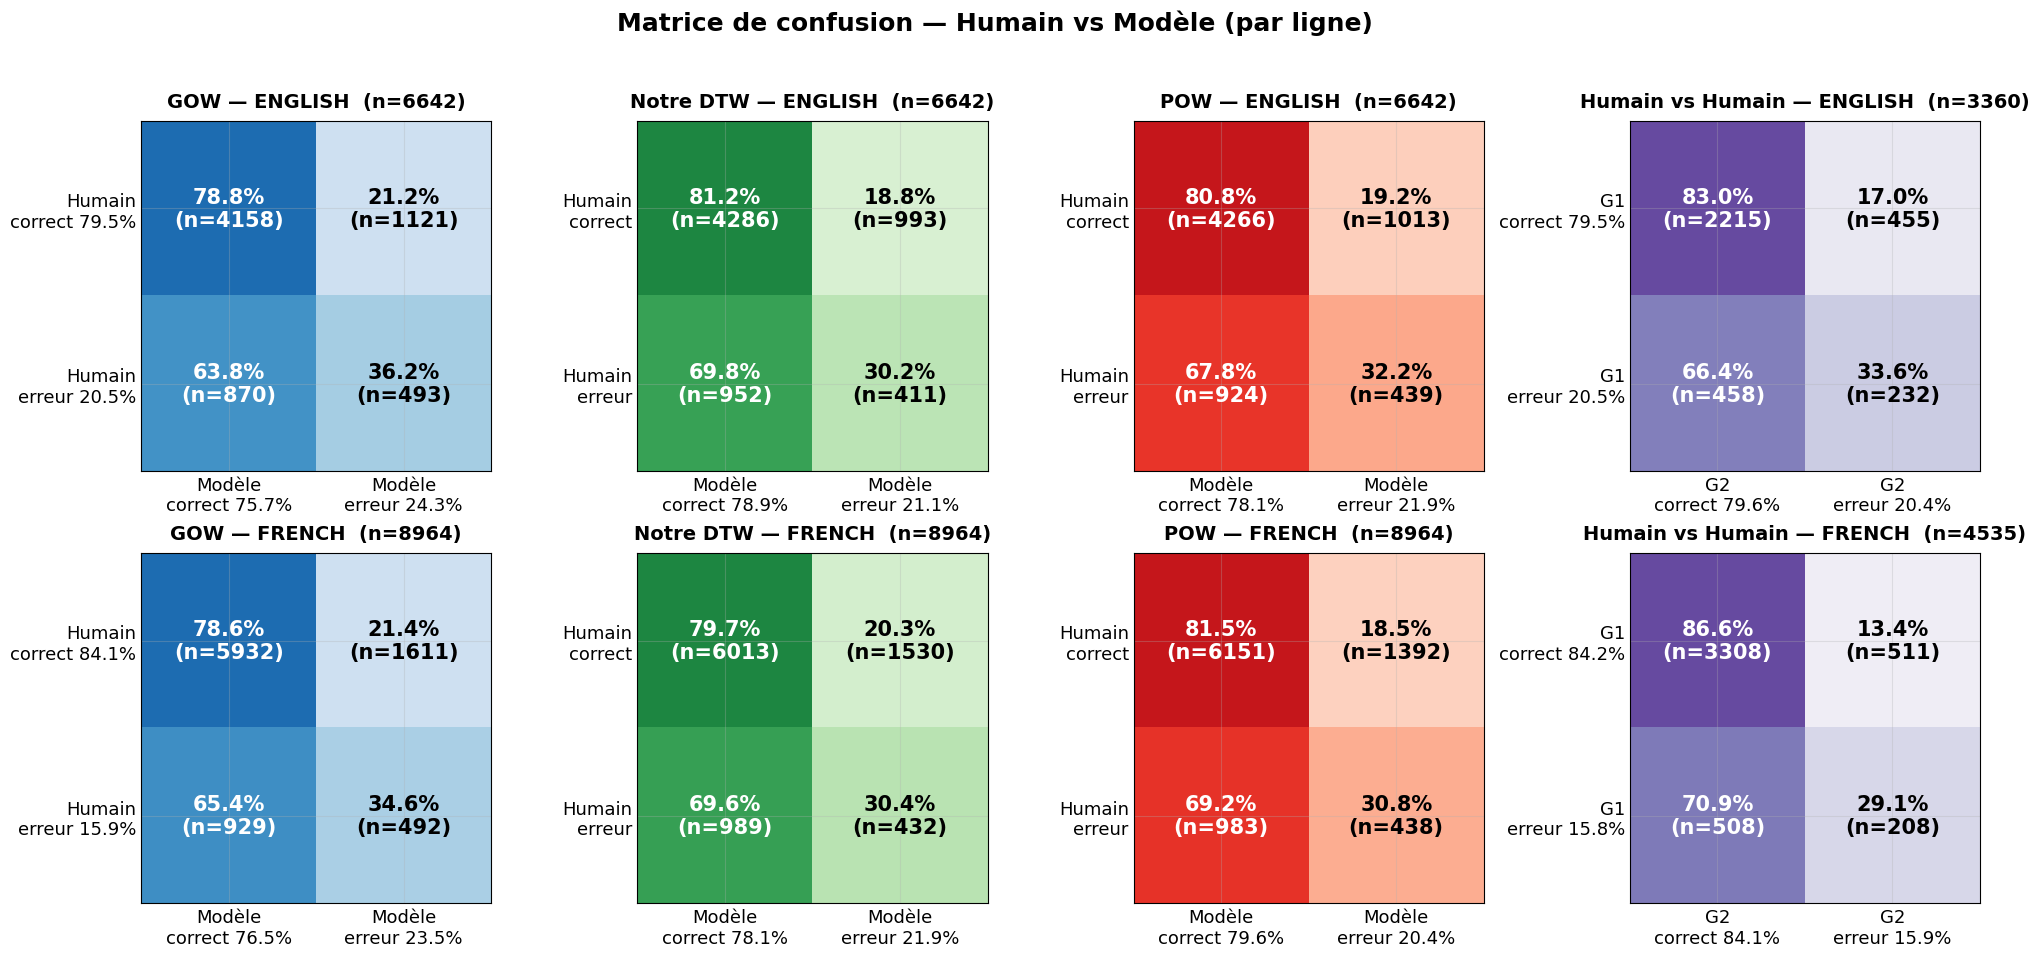

In [13]:
plot_confusion_matrices(
    chemin_gow="matrices_mfcc_sauvegardees/resultats_gow_WO_OT.csv",
    chemin_pow="matrices_mfcc_sauvegardees/resultats_pow_WO_OT.csv",
)

In [ ]:
from scipy.stats import pearsonr

def bootstrap_human_ceiling_RC(chemin_csv, n_bootstrap=1000, seed=42):
    rng = np.random.default_rng(seed)
    df = charger_et_corriger(chemin_csv)

    if 'triplet_id' not in df.columns:
        df['triplet_id'] = (df['language'].astype(str) + "_" +
                            df['prev_phone'].astype(str) + "-" +
                            df['next_phone'].astype(str) + "-" +
                            df['TGT'].astype(str) + "-" +
                            df['OTH'].astype(str))

    df_ch = df[df['correct_answer'].notna()].copy()
    participants = df_ch['individual'].unique()
    
    pearson_scores = [] # Pour stocker les R
    matrices_contingence = [] # Pour stocker les C

    for _ in tqdm(range(n_bootstrap), desc="Bootstrap Human vs Human (R et C)"):
        rng.shuffle(participants)
        mid = len(participants) // 2

        # Moyenne par triplet pour chaque groupe
        score1 = df_ch[df_ch['individual'].isin(participants[:mid])].groupby('triplet_id')['correct_answer'].mean().rename('h1')
        score2 = df_ch[df_ch['individual'].isin(participants[mid:])].groupby('triplet_id')['correct_answer'].mean().rename('h2')

        merged = pd.merge(score1, score2, on='triplet_id').dropna()
        if len(merged) < 10:
            continue

        # 1. Calcul du R (Pearson)
        r, _ = pearsonr(merged['h1'], merged['h2'])
        pearson_scores.append(r)
        
        # 2. Calcul du C (Matrice de contingence)
        # On considère "Correct" si le score moyen du groupe est > 0
        h1_correct = merged['h1'] > 0
        h2_correct = merged['h2'] > 0
        
        # Cellules de la matrice 2x2
        both_correct = (h1_correct & h2_correct).sum()
        h1_correct_h2_error = (h1_correct & ~h2_correct).sum()
        h1_error_h2_correct = (~h1_correct & h2_correct).sum()
        both_error = (~h1_correct & ~h2_correct).sum()
        
        matrice_C = np.array([
            [both_correct, h1_correct_h2_error],
            [h1_error_h2_correct, both_error]
        ])
        
        # On stocke les proportions (pourcentage) pour que ce soit comparable avec tes autres matrices
        matrice_C_prop = matrice_C / matrice_C.sum()
        matrices_contingence.append(matrice_C_prop)

    # Moyennes finales ("R moyen et C moyen" demandés par le prof)
    r_moy = np.mean(pearson_scores)
    r_std = np.std(pearson_scores)
    c_moy = np.mean(matrices_contingence, axis=0) * 100 # En pourcentage

    print(f"\n{'='*55}")
    print(f"  Plafond Humain (Bootstrap R et C, n={n_bootstrap})")
    print(f"{'='*55}")
    print(f"  [R] Pearson moyen : {r_moy:.4f} ± {r_std:.4f}")
    print(f"{'-'*55}")
    print(f"  [C] Matrice de Contingence moyenne (en %) :")
    print(f"       G2 Correct | G2 Erreur")
    print(f"  G1 C |  {c_moy[0,0]:5.1f}%  |  {c_moy[0,1]:5.1f}%")
    print(f"  G1 E |  {c_moy[1,0]:5.1f}%  |  {c_moy[1,1]:5.1f}%")
    print(f"{'='*55}")

    return {'pearson_mean': r_moy, 'contingence_mean': c_moy}

ceiling = bootstrap_human_ceiling_RC(
    chemin_csv="matrices_mfcc_sauvegardees/resultats_gow_WO_OT.csv",
    n_bootstrap=1000
)

Bootstrap Human vs Human (R et C): 100%|██████████| 1000/1000 [00:06<00:00, 144.47it/s]


  Plafond Humain (Bootstrap R et C, n=1000)
  [R] Pearson moyen : 0.4094 ± 0.0129
-------------------------------------------------------
  [C] Matrice de Contingence moyenne (en %) :
       G2 Correct | G2 Erreur
  G1 C |   79.7%  |    8.2%
  G1 E |    8.2%  |    3.9%


In [15]:
def bootstrap_human_ceiling_RC(chemin_csv, n_bootstrap=1000, seed=42):
    rng = np.random.default_rng(seed)
    df = charger_et_corriger(chemin_csv)

    # Garder uniquement les lignes humaines valides
    df_ch = df[df['correct_answer'].notna()].copy()
    participants = df_ch['individual'].unique()

    pearson_scores = []
    matrices_contingence = []

    for _ in tqdm(range(n_bootstrap), desc="Bootstrap Human vs Human (R et C)"):
        rng.shuffle(participants)
        mid = len(participants) // 2

        df1 = df_ch[df_ch['individual'].isin(participants[:mid])]
        df2 = df_ch[df_ch['individual'].isin(participants[mid:])]

        # ── PAR LIGNE : merge sur filename + individual pour garder les essais bruts ──
        # On prend les colonnes nécessaires de chaque groupe
        cols = ['filename', 'correct_answer']
        merged = pd.merge(
            df1[cols].rename(columns={'correct_answer': 'h1'}),
            df2[cols].rename(columns={'correct_answer': 'h2'}),
            on='filename'
        ).dropna()

        if len(merged) < 10:
            continue

        # 1. R (Pearson sur les scores bruts ligne à ligne)
        r, _ = pearsonr(merged['h1'], merged['h2'])
        pearson_scores.append(r)

        # 2. C (Matrice de contingence ligne à ligne)
        h1_correct = merged['h1'] > 0
        h2_correct = merged['h2'] > 0

        matrice_C = np.array([
            [(h1_correct  &  h2_correct).sum(), (h1_correct  & ~h2_correct).sum()],
            [(~h1_correct &  h2_correct).sum(), (~h1_correct & ~h2_correct).sum()],
        ])

        matrices_contingence.append(matrice_C / matrice_C.sum())

    r_moy = np.mean(pearson_scores)
    r_std = np.std(pearson_scores)
    c_moy = np.mean(matrices_contingence, axis=0) * 100

    print(f"\n{'='*55}")
    print(f"  Plafond Humain PAR LIGNE (Bootstrap R et C, n={n_bootstrap})")
    print(f"{'='*55}")
    print(f"  [R] Pearson moyen : {r_moy:.4f} ± {r_std:.4f}")
    print(f"{'-'*55}")
    print(f"  [C] Matrice de Contingence moyenne (en %) :")
    print(f"       G2 Correct | G2 Erreur")
    print(f"  G1 C |  {c_moy[0,0]:5.1f}%  |  {c_moy[0,1]:5.1f}%")
    print(f"  G1 E |  {c_moy[1,0]:5.1f}%  |  {c_moy[1,1]:5.1f}%")
    print(f"{'='*55}")

    return {'pearson_mean': r_moy, 'contingence_mean': c_moy}

ceiling = bootstrap_human_ceiling_RC(
    chemin_csv="matrices_mfcc_sauvegardees/resultats_gow_WO_OT.csv",
    n_bootstrap=1000
)

Bootstrap Human vs Human (R et C): 100%|██████████| 1000/1000 [00:04<00:00, 205.74it/s]


  Plafond Humain PAR LIGNE (Bootstrap R et C, n=1000)
  [R] Pearson moyen : 0.2396 ± 0.0084
-------------------------------------------------------
  [C] Matrice de Contingence moyenne (en %) :
       G2 Correct | G2 Erreur
  G1 C |   69.9%  |   12.3%
  G1 E |   12.2%  |    5.6%


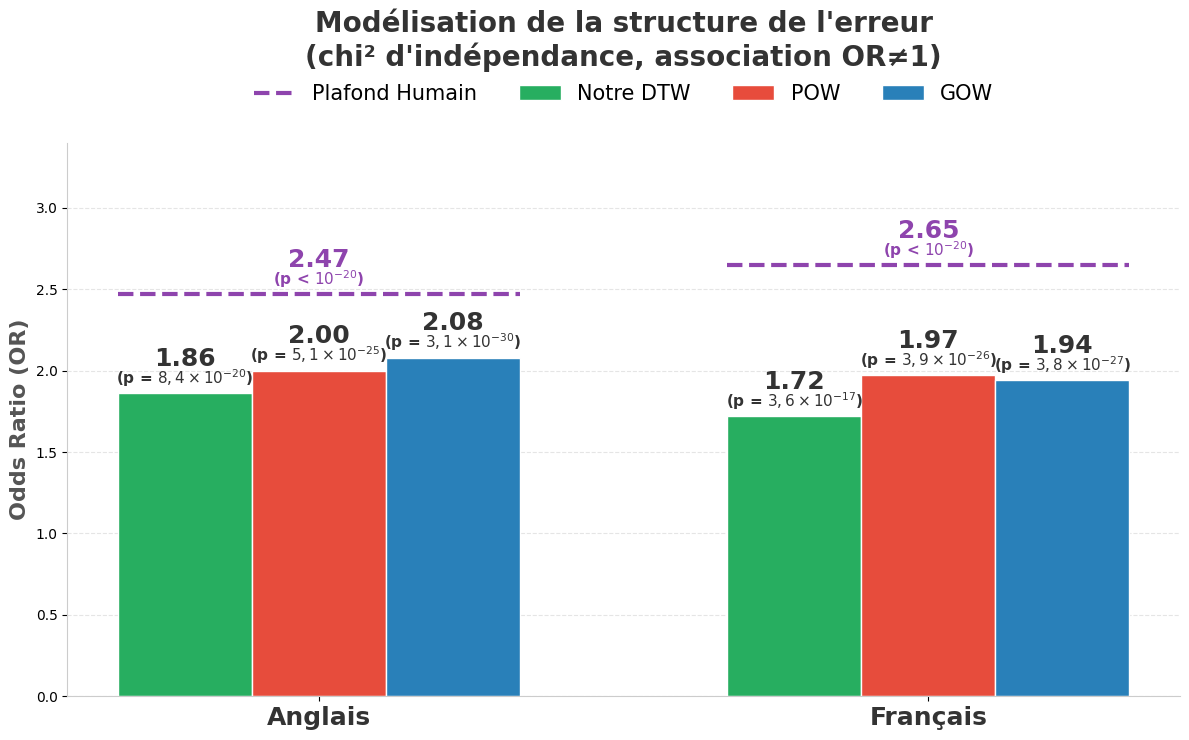

In [ ]:
# 1. Données hardcodées
langues = ['Anglais', 'Français']
dtw_or = [1.86, 1.72]
pow_or = [2.00, 1.97]
gow_or = [2.08, 1.94]
plafond_humain = [2.47, 2.65]

# p-values du CHI² D'INDÉPENDANCE 
dtw_p = [r'p = $8,4 \times 10^{-20}$', r'p = $3,6 \times 10^{-17}$']
pow_p = [r'p = $5,1 \times 10^{-25}$', r'p = $3,9 \times 10^{-26}$']
gow_p = [r'p = $3,1 \times 10^{-30}$', r'p = $3,8 \times 10^{-27}$']

# Plafond humain : p issu du bootstrap 
plafond_p = [r'p < $10^{-20}$', r'p < $10^{-20}$']

# 2. Paramètres graphiques
x = np.arange(len(langues))
width = 0.22

color_dtw = '#27ae60'
color_pow = '#e74c3c'
color_gow = '#2980b9'
color_humain = '#8e44ad'

fig, ax = plt.subplots(figsize=(12, 7.5))

# 3. Barres groupées
rects1 = ax.bar(x - width, dtw_or, width, label='Notre DTW', color=color_dtw, edgecolor='white')
rects2 = ax.bar(x, pow_or, width, label='POW', color=color_pow, edgecolor='white')
rects3 = ax.bar(x + width, gow_or, width, label='GOW', color=color_gow, edgecolor='white')

# 4. Plafond humain
ax.hlines(plafond_humain[0], x[0] - width*1.5, x[0] + width*1.5,
          colors=color_humain, linestyles='dashed', linewidth=3, label='Plafond Humain')
ax.hlines(plafond_humain[1], x[1] - width*1.5, x[1] + width*1.5,
          colors=color_humain, linestyles='dashed', linewidth=3)

for i in range(2):
    ax.annotate(f'{plafond_humain[i]:.2f}', xy=(x[i], plafond_humain[i]), xytext=(0, 16),
                textcoords="offset points", ha='center', va='bottom',
                color=color_humain, fontweight='bold', fontsize=18)
    ax.annotate(f'({plafond_p[i]})', xy=(x[i], plafond_humain[i]), xytext=(0, 3),
                textcoords="offset points", ha='center', va='bottom',
                color=color_humain, fontweight='bold', fontsize=11)

# 5. Fonction d'annotation OR + p
def autolabel(rects, p_values):
    for i, rect in enumerate(rects):
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 16), textcoords="offset points",
                    ha='center', va='bottom', fontsize=18, fontweight='bold', color='#333333')
        ax.annotate(f'({p_values[i]})',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold', color='#333333')

autolabel(rects1, dtw_p)
autolabel(rects2, pow_p)
autolabel(rects3, gow_p)

# 6. Esthétique
ax.set_ylabel("Odds Ratio (OR)", fontsize=16, fontweight='bold', color='#555555')
ax.set_title("Modélisation de la structure de l'erreur\n(chi² d'indépendance, association OR≠1)",
              fontsize=20, fontweight='bold', pad=55, color='#333333')
ax.set_xticks(x)
ax.set_xticklabels(langues, fontsize=18, fontweight='bold', color='#333333')
ax.set_ylim(0, 3.4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.set_axisbelow(True)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.14), ncol=4, frameon=False, fontsize=15)

fig.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, chi2_contingency
from tqdm import tqdm

def plot_confusion_matrices_by_triplet(chemin_gow, chemin_pow, figsize=(20, 5), n_bootstrap=1000, seed=42):
    df_gow = charger_et_corriger(chemin_gow)
    df_pow = charger_et_corriger(chemin_pow)

    # Création du triplet_id pour les deux DataFrames (identique au script de corrélation)
    for df in [df_gow, df_pow]:
        if 'triplet_id' not in df.columns:
            df['triplet_id'] = (
                df['language'].astype(str) + "_" +
                df['prev_phone'].astype(str) + "-" +
                df['next_phone'].astype(str) + "-" +
                df['TGT'].astype(str) + "-" +
                df['OTH'].astype(str)
            )

    configs = [
        {'df': df_gow, 'col_model': 'Delta_Machine_DTW_PERSO', 'label': 'Notre DTW',        'cmap': 'Greens'},
        {'df': df_gow, 'col_model': 'Delta_Machine_GOW',       'label': 'GOW',              'cmap': 'Blues'},
        {'df': df_pow, 'col_model': 'Delta_Machine_POW',       'label': 'POW',              'cmap': 'Reds'},
        {'df': df_gow, 'col_model': 'Humain',                  'label': 'Humain vs Humain', 'cmap': 'Purples'},
    ]

    langues = sorted(df_gow['language'].dropna().unique())

    fig, axes = plt.subplots(len(langues), len(configs),
                             figsize=(figsize[0], figsize[1] * len(langues)))
    if len(langues) == 1:
        axes = [axes]

    rng = np.random.default_rng(seed)

    for i, langue in enumerate(langues):
        for j, cfg in enumerate(configs):
            ax = axes[i][j]
            df = cfg['df']
            col = cfg['col_model']

            mask = (df['language'] == langue) & df['correct_answer'].notna()
            if col != 'Humain':
                mask = mask & df[col].notna()
            df_lang = df[mask].copy()

            if cfg['label'] == 'Humain vs Humain':
                # --- BOOTSTRAP PLAFOND HUMAIN, AGRÉGÉ PAR TRIPLET ---
                participants = df_lang['individual'].unique()
                matrices_counts = []

                for _ in range(n_bootstrap):
                    rng.shuffle(participants)
                    mid = len(participants) // 2

                    df1 = df_lang[df_lang['individual'].isin(participants[:mid])]
                    df2 = df_lang[df_lang['individual'].isin(participants[mid:])]

                    # Agrégation par triplet_id avant de comparer les deux groupes
                    agg1 = df1.groupby('triplet_id')['correct_answer'].mean().rename('h1')
                    agg2 = df2.groupby('triplet_id')['correct_answer'].mean().rename('h2')

                    merged = pd.merge(agg1, agg2, on='triplet_id').dropna()

                    if len(merged) < 10:
                        continue

                    h1_correct = merged['h1'] > 0
                    h2_correct = merged['h2'] > 0

                    matrice_C = np.array([
                        [(h1_correct  &  h2_correct).sum(), (h1_correct  & ~h2_correct).sum()],
                        [(~h1_correct &  h2_correct).sum(), (~h1_correct & ~h2_correct).sum()],
                    ])
                    matrices_counts.append(matrice_C)

                counts = np.mean(matrices_counts, axis=0).astype(int)
                total1 = counts[0].sum()
                total2 = counts[1].sum()

                props1 = counts[0] / total1 if total1 > 0 else np.array([0, 0])
                props2 = counts[1] / total2 if total2 > 0 else np.array([0, 0])
                props = np.array([props1, props2])

                total_all = total1 + total2
                humain_correct_accuracy = total1 / total_all if total_all > 0 else 0
                model_correct_accuracy = (counts[0, 0] + counts[1, 0]) / total_all if total_all > 0 else 0

            else:
                # --- LOGIQUE MODÈLE, AGRÉGÉE PAR TRIPLET ---
                df_agg = df_lang.groupby('triplet_id').agg(
                    {col: 'mean', 'correct_answer': 'mean'}
                ).reset_index()

                humain_correct = df_agg['correct_answer'] > 0
                model_correct  = df_agg[col] > 0

                humain_correct_accuracy = df_agg[humain_correct].shape[0] / df_agg.shape[0]
                model_correct_accuracy = df_agg[model_correct].shape[0] / df_agg.shape[0]

                counts = np.array([
                    [(humain_correct  &  model_correct).sum(), (humain_correct  & ~model_correct).sum()],
                    [(~humain_correct &  model_correct).sum(), (~humain_correct & ~model_correct).sum()],
                ])

                total1 = counts[0].sum()
                total2 = counts[1].sum()
                props1 = counts[0] / total1 if total1 > 0 else np.array([0, 0])
                props2 = counts[1] / total2 if total2 > 0 else np.array([0, 0])
                props = np.array([props1, props2])

            ax.imshow(props, cmap=cfg['cmap'], vmin=0, vmax=props.max() * 1.3)

            for r in range(2):
                for c in range(2):
                    ax.text(c, r,
                            f"{props[r,c]*100:.1f}%\n(n={counts[r,c]})",
                            ha='center', va='center', fontsize=15, fontweight='bold',
                            color='white' if props[r,c] > props.max() * 0.6 else 'black')

            ax.set_xticks([0, 1])
            ax.set_yticks([0, 1])
            ax.set_xticklabels([f"{'G2' if cfg['label'] == 'Humain vs Humain' else 'Modèle'}\ncorrect {model_correct_accuracy*100:.1f}%",
                                f"{'G2' if cfg['label'] == 'Humain vs Humain' else 'Modèle'}\nerreur {100 - model_correct_accuracy*100:.1f}%"], fontsize=13)

            if cfg['label'] == 'Humain vs Humain':
                ax.set_yticklabels([f"G1\ncorrect {humain_correct_accuracy*100:.1f}%",
                                    f"G1\nerreur {100 - humain_correct_accuracy*100:.1f}%"], fontsize=13)
            elif j == 0:
                ax.set_yticklabels([f"Humain\ncorrect {humain_correct_accuracy*100:.1f}%",
                                    f"Humain\nerreur {100 - humain_correct_accuracy*100:.1f}%"], fontsize=13)
            else:
                ax.set_yticklabels(["Humain\ncorrect", "Humain\nerreur"], fontsize=13)

            ax.set_title(f"{cfg['label']} — {str(langue).upper()}  (n={total1 + total2} triplets)",
                         fontsize=14, fontweight='bold', pad=10)
            ax.tick_params(length=0)
            ax.grid(alpha=0.3)

            A, B = counts[0, 0], counts[0, 1]
            C, D = counts[1, 0], counts[1, 1]

            odds_ratio = (A * D) / (B * C) if (B * C) != 0 else np.nan
            chi2_mcnemar = ((abs(B - C) - 1)**2) / (B + C) if (B + C) != 0 else np.nan
            p_mcnemar = chi2.sf(chi2_mcnemar, 1)
            chi2_stat, p_indep, dof, expected = chi2_contingency(counts, correction=True)

            print(f"[{langue}] {cfg['label']:<17} | Odds Ratio : {odds_ratio:.2f} "
                  f"| McNemar p (symétrie) : {p_mcnemar:.4e} "
                  f"| Chi2 indep p (association) : {p_indep:.4e}")

    plt.suptitle("Matrice de confusion — Humain vs Modèle (agrégé par triplet)",
                 fontsize=18, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [24]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

def plot_correlations_by_language_rowwise(chemin_gow, chemin_pow, figsize=(18, 10)):
    df_gow = charger_et_corriger(chemin_gow)
    df_pow = charger_et_corriger(chemin_pow)

    langues = df_gow['language'].dropna().unique()

    configs = [
        {'df': df_gow, 'col_model': 'Delta_Machine_DTW_PERSO', 'label': 'Notre DTW', 'color': 'seagreen'},
        {'df': df_gow, 'col_model': 'Delta_Machine_GOW',       'label': 'GOW', 'color': 'steelblue'},
        {'df': df_pow, 'col_model': 'Delta_Machine_POW',       'label': 'POW', 'color': 'tomato'},
    ]

    TITLE_FS  = 16
    LABEL_FS  = 13
    TICK_FS   = 12
    SUPTITLE_FS = 20

    fig, axes = plt.subplots(len(langues), len(configs), figsize=figsize)
    if len(langues) == 1:
        axes = [axes]

    for i, langue in enumerate(langues):
        for j, cfg in enumerate(configs):
            ax = axes[i][j]
            df = cfg['df']
            col_model = cfg['col_model']

            mask = (
                (df['language'] == langue) &
                df['correct_answer'].notna() &
                df[col_model].notna()
            )
            df_clean = df[mask]

            # Pas d'agrégation par triplet_id : chaque essai (ligne) est un point du nuage
            x_raw = df_clean[col_model].values
            y_raw = df_clean['correct_answer'].values

            def norm(v):
                vmin, vmax = v.min(), v.max()
                if vmax == vmin:
                    return np.zeros_like(v)
                return (v - vmin) / (vmax - vmin)

            x = norm(x_raw)
            y = norm(y_raw)

            slope, intercept, r, p, _ = linregress(x, y)

            # Nuage plus dense qu'au niveau triplet : points plus petits et plus transparents
            ax.scatter(x, y, alpha=0.25, s=8, color=cfg['color'])
            x_line = np.linspace(0, 1, 200)
            ax.plot(x_line, slope * x_line + intercept, color='black', linewidth=1.5)
            ax.set_xlim(-0.05, 1.05)
            ax.set_ylim(-0.05, 1.05)

            titre = f"{cfg['label']} - {str(langue).upper()}\nr = {r:.3f}  (p = {p:.2e}, n={len(x)})"
            ax.set_title(titre, fontsize=TITLE_FS, fontweight='bold')

            ax.tick_params(axis='both', labelsize=TICK_FS)
            if i == len(langues) - 1:
                ax.set_xlabel(f"Delta {cfg['label']} (normalisé)", fontsize=LABEL_FS)
            if j == 0:
                ax.set_ylabel(f"Score humain ({str(langue).capitalize()})", fontsize=LABEL_FS)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

    plt.suptitle(
        "Corrélation Modèle vs Humain, par essai (sans agrégation)",
        fontsize=SUPTITLE_FS, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.show()